In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from my_nn import activations, loss, metrics, nn
from data.sample_data import generate_data, plot_data

In [2]:
# first get the data
data, targets = generate_data(seed=42)

#### For this notebook we will be looking at the binary classification using the target defined by a piecewise linear boundary.

In [4]:
# set up X, y for training
# use numpy arrays here for now so train test split works properly
X = np.array(data[["x1","x2"]])
y = np.array(data["binary_pl"])
data_used = data[["x1","x2","binary_pl"]].copy()

In [5]:
# do a train_test split
X_train, X_test, y_train, y_test = nn.train_test_split(X, y, test_size = 0.2, random_state=42)

In [6]:
# create 3 versions of the model to train. These will be identical here, and will only differ in how the .fit() is called
model_sgd = nn.FeedForward(
    nn.Dense(2, 30, activation="relu"),
    nn.Dense(30, 30, activation="relu"),
    nn.Dense(30, 30, activation="relu"),
    nn.Dense(30, 1, activation="sigmoid")
)

model_momentum = nn.FeedForward(
    nn.Dense(2, 30, activation="relu"),
    nn.Dense(30, 30, activation="relu"),
    nn.Dense(30, 30, activation="relu"),
    nn.Dense(30, 1, activation="sigmoid")
)

model_adam = nn.FeedForward(
    nn.Dense(2, 30, activation="relu"),
    nn.Dense(30, 30, activation="relu"),
    nn.Dense(30, 30, activation="relu"),
    nn.Dense(30, 1, activation="sigmoid")
)

In [7]:
# train the models
history_sgd = model_sgd.fit(
    X_train,
    y_train,
    epochs=200,
    learning_rate=0.01,
    batch_size=32,
    verbose=False,
    loss_fn="binary_cross_entropy",
    metric="accuracy",
    val_size = 0.2,
    optimizer="sgd"
)

Epoch 1 complete. Average Loss: 0.4700 , accuracy 0.8825 -  Validation Loss: 0.3049, Validation accuracy 0.8906
Epoch 2 complete. Average Loss: 0.2920 , accuracy 0.9031 -  Validation Loss: 0.2607, Validation accuracy 0.9075
Epoch 3 complete. Average Loss: 0.2583 , accuracy 0.9094 -  Validation Loss: 0.2376, Validation accuracy 0.9144
Epoch 4 complete. Average Loss: 0.2392 , accuracy 0.9098 -  Validation Loss: 0.2230, Validation accuracy 0.9163
Epoch 5 complete. Average Loss: 0.2265 , accuracy 0.9108 -  Validation Loss: 0.2129, Validation accuracy 0.9181
Epoch 6 complete. Average Loss: 0.2174 , accuracy 0.9120 -  Validation Loss: 0.2055, Validation accuracy 0.9175
Epoch 7 complete. Average Loss: 0.2103 , accuracy 0.9128 -  Validation Loss: 0.1997, Validation accuracy 0.9169
Epoch 8 complete. Average Loss: 0.2048 , accuracy 0.9136 -  Validation Loss: 0.1952, Validation accuracy 0.9181
Epoch 9 complete. Average Loss: 0.2003 , accuracy 0.9139 -  Validation Loss: 0.1912, Validation accuracy

In [8]:
history_momentum = model_momentum.fit(
    X_train,
    y_train,
    epochs=200,
    learning_rate=0.01,
    batch_size=32,
    verbose=False,
    loss_fn="binary_cross_entropy",
    metric="accuracy",
    val_size = 0.2,
    optimizer="momentum"
)

Epoch 1 complete. Average Loss: 0.4290 , accuracy 0.9062 -  Validation Loss: 0.3386, Validation accuracy 0.9144
Epoch 2 complete. Average Loss: 0.3095 , accuracy 0.9100 -  Validation Loss: 0.2872, Validation accuracy 0.9169
Epoch 3 complete. Average Loss: 0.2723 , accuracy 0.9116 -  Validation Loss: 0.2577, Validation accuracy 0.9175
Epoch 4 complete. Average Loss: 0.2492 , accuracy 0.9130 -  Validation Loss: 0.2382, Validation accuracy 0.9194
Epoch 5 complete. Average Loss: 0.2334 , accuracy 0.9137 -  Validation Loss: 0.2242, Validation accuracy 0.9194
Epoch 6 complete. Average Loss: 0.2218 , accuracy 0.9148 -  Validation Loss: 0.2137, Validation accuracy 0.9181
Epoch 7 complete. Average Loss: 0.2130 , accuracy 0.9150 -  Validation Loss: 0.2055, Validation accuracy 0.9169
Epoch 8 complete. Average Loss: 0.2060 , accuracy 0.9156 -  Validation Loss: 0.1989, Validation accuracy 0.9169
Epoch 9 complete. Average Loss: 0.2003 , accuracy 0.9152 -  Validation Loss: 0.1935, Validation accuracy

In [9]:
history_adam = model_adam.fit(
    X_train,
    y_train,
    epochs=200,
    learning_rate=0.01,
    batch_size=32,
    verbose=False,
    loss_fn="binary_cross_entropy",
    metric="accuracy",
    val_size = 0.2,
    optimizer="adam"
)

Epoch 1 complete. Average Loss: 0.1366 , accuracy 0.9759 -  Validation Loss: 0.0524, Validation accuracy 0.9750
Epoch 2 complete. Average Loss: 0.0372 , accuracy 0.9894 -  Validation Loss: 0.0267, Validation accuracy 0.9888
Epoch 3 complete. Average Loss: 0.0417 , accuracy 0.9867 -  Validation Loss: 0.0248, Validation accuracy 0.9862
Epoch 4 complete. Average Loss: 0.0293 , accuracy 0.9941 -  Validation Loss: 0.0162, Validation accuracy 0.9931
Epoch 5 complete. Average Loss: 0.0227 , accuracy 0.9978 -  Validation Loss: 0.0120, Validation accuracy 0.9981
Epoch 6 complete. Average Loss: 0.0225 , accuracy 0.9952 -  Validation Loss: 0.0120, Validation accuracy 0.9962
Epoch 7 complete. Average Loss: 0.0298 , accuracy 0.9900 -  Validation Loss: 0.0255, Validation accuracy 0.9888
Epoch 8 complete. Average Loss: 0.0206 , accuracy 0.9928 -  Validation Loss: 0.0164, Validation accuracy 0.9944
Epoch 9 complete. Average Loss: 0.0233 , accuracy 0.9852 -  Validation Loss: 0.0408, Validation accuracy

c:\Users\ronsp\IdeaProjects\neural_networks\my_nn\activations.py:28: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))


 Validation Loss: 0.0047, Validation accuracy 0.9988
Epoch 98 complete. Average Loss: 0.0049 , accuracy 0.9967 -  Validation Loss: 0.0064, Validation accuracy 0.9969
Epoch 99 complete. Average Loss: 0.0077 , accuracy 0.9989 -  Validation Loss: 0.0045, Validation accuracy 0.9994
Epoch 100 complete. Average Loss: 0.0068 , accuracy 0.9973 -  Validation Loss: 0.0149, Validation accuracy 0.9956
Epoch 101 complete. Average Loss: 0.0088 , accuracy 0.9911 -  Validation Loss: 0.0407, Validation accuracy 0.9881
Epoch 102 complete. Average Loss: 0.0051 , accuracy 0.9975 -  Validation Loss: 0.0121, Validation accuracy 0.9956
Epoch 103 complete. Average Loss: 0.0093 , accuracy 0.9914 -  Validation Loss: 0.0735, Validation accuracy 0.9881
Epoch 104 complete. Average Loss: 0.0074 , accuracy 0.9975 -  Validation Loss: 0.0136, Validation accuracy 0.9962
Epoch 105 complete. Average Loss: 0.0094 , accuracy 0.9970 -  Validation Loss: 0.0062, Validation accuracy 0.9981
Epoch 106 complete. Average Loss: 0.0

#### Let's look at the histories of each

##### First for standard gradient descent

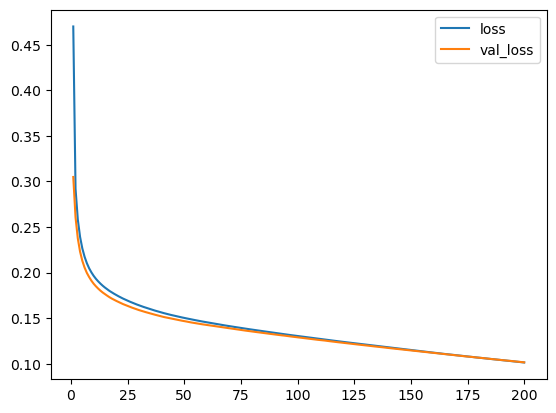

In [10]:
nn.plot_history(history_sgd, "loss", "val_loss")

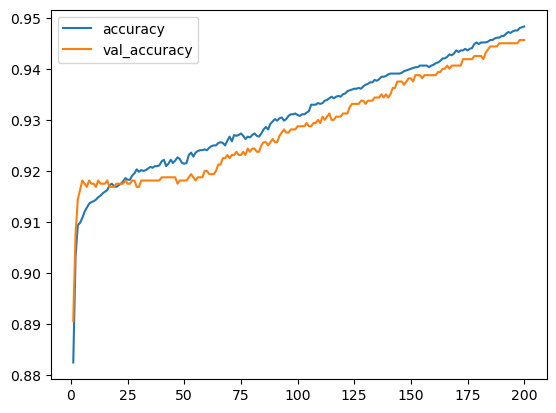

In [11]:
nn.plot_history(history_sgd, "accuracy", "val_accuracy")

##### Next, for momentum

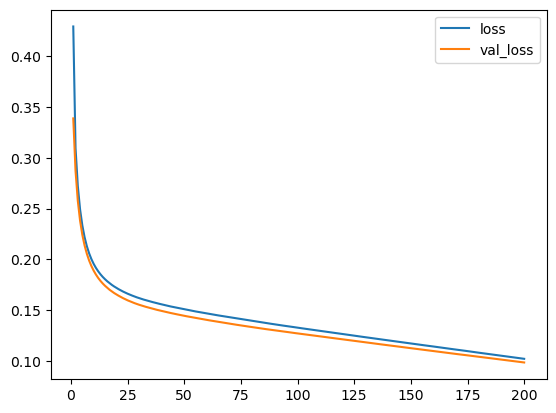

In [12]:
nn.plot_history(history_momentum, "loss", "val_loss")

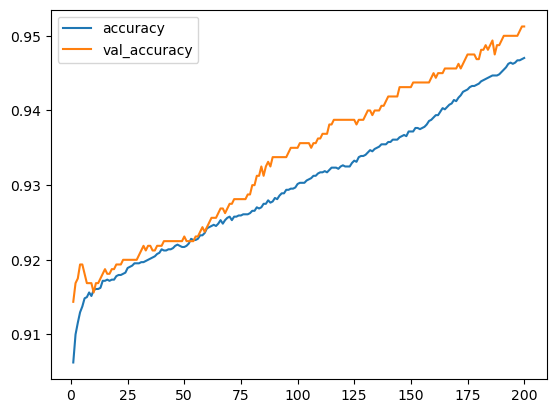

In [13]:
nn.plot_history(history_momentum, "accuracy", "val_accuracy")

##### Finally for adam optimization

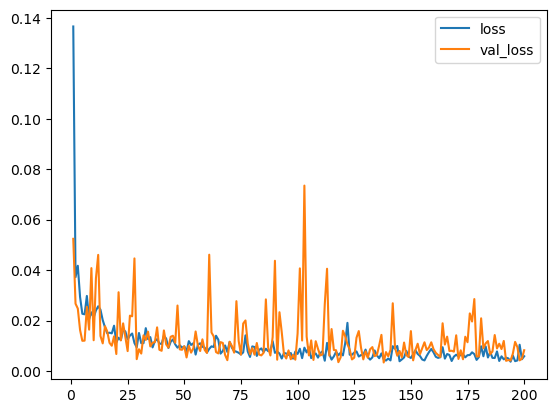

In [14]:
nn.plot_history(history_adam, "loss", "val_loss")

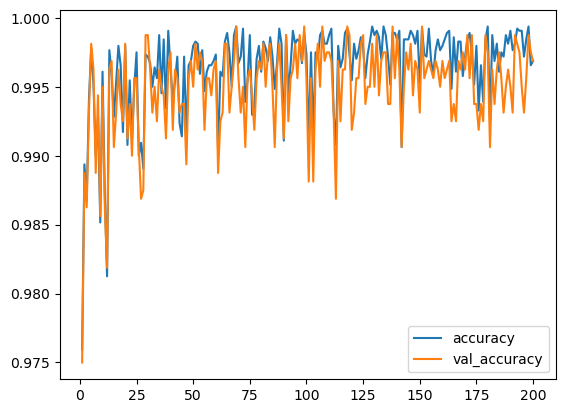

In [15]:
nn.plot_history(history_adam, "accuracy", "val_accuracy")

#### Now let's see how these do on unseen test data

In [16]:
y_pred_sgd = model_sgd.predict(X_test)
y_pred_momentum = model_momentum.predict(X_test)
y_pred_adam = model_adam.predict(X_test)

In [17]:
print("SGD all real numbers: ", np.isfinite(y_pred_sgd).all())
print("Momentum all real numbers: ",np.isfinite(y_pred_momentum).all())
print("Adam all real numbers: ", np.isfinite(y_pred_adam).all())

SGD all real numbers:  True
Momentum all real numbers:  True
Adam all real numbers:  True


In [18]:
# convert to 0,1 for use in metrics
y_labels_sgd = (y_pred_sgd >= 0.5).astype(int)
y_labels_momentum = (y_pred_momentum>=0.5).astype(int)
y_labels_adam = (y_pred_adam>=0.5).astype(int)

In [19]:
acc_sgd = metrics.accuracy(y_test, y_labels_sgd)
acc_mom = metrics.accuracy(y_test, y_labels_momentum)
acc_adam = metrics.accuracy(y_test, y_labels_adam)

precision_sgd = metrics.precision(y_test, y_labels_sgd)
precision_mom = metrics.precision(y_test, y_labels_momentum)
precision_adam = metrics.precision(y_test, y_labels_adam)

recall_sgd = metrics.recall(y_test, y_labels_sgd)
recall_mom = metrics.recall(y_test, y_labels_momentum)
recall_adam = metrics.recall(y_test, y_labels_adam)

f1_sgd = metrics.f1_score(y_test, y_labels_sgd)
f1_mom = metrics.f1_score(y_test, y_labels_momentum)
f1_adam = metrics.f1_score(y_test, y_labels_adam)

spec_sgd = metrics.specificity(y_test, y_labels_sgd)
spec_mom = metrics.specificity(y_test, y_labels_momentum)
spec_adam = metrics.specificity(y_test, y_labels_adam)

bal_acc_sgd = metrics.balanced_accuracy(y_test, y_labels_sgd)
bal_acc_mom = metrics.balanced_accuracy(y_test, y_labels_momentum)
bal_acc_adam = metrics.balanced_accuracy(y_test, y_labels_adam)

In [20]:
print("For Standard Gradient Descent")
print("-----------------------------")
print(f"Accuracy: {acc_sgd: .4f}")
print(f"Precision: {precision_sgd: .4f}")
print(f"Recall: {recall_sgd: .4f}")
print(f"F1 Score: {f1_sgd: .4f}")
print(f"Specificity: {spec_sgd: .4f}")
print(f"Balanced Accuracy: {bal_acc_sgd: .4f}")

For Standard Gradient Descent
-----------------------------
Accuracy:  0.9520
Precision:  0.9066
Recall:  0.9855
F1 Score:  0.9444
Specificity:  0.9284
Balanced Accuracy:  0.9569


In [21]:
print("For using momentum")
print("-----------------------------")
print(f"Accuracy: {acc_mom: .4f}")
print(f"Precision: {precision_mom: .4f}")
print(f"Recall: {recall_mom: .4f}")
print(f"F1 Score: {f1_mom: .4f}")
print(f"Specificity: {spec_mom: .4f}")
print(f"Balanced Accuracy: {bal_acc_mom: .4f}")

For using momentum
-----------------------------
Accuracy:  0.9540
Precision:  0.9110
Recall:  0.9856
F1 Score:  0.9468
Specificity:  0.9316
Balanced Accuracy:  0.9586


In [22]:
print("For Adam optimization")
print("-----------------------------")
print(f"Accuracy: {acc_adam: .4f}")
print(f"Precision: {precision_adam: .4f}")
print(f"Recall: {recall_adam: .4f}")
print(f"F1 Score: {f1_adam: .4f}")
print(f"Specificity: {spec_adam: .4f}")
print(f"Balanced Accuracy: {bal_acc_adam: .4f}")

For Adam optimization
-----------------------------
Accuracy:  0.9975
Precision:  0.9944
Recall:  1.0000
F1 Score:  0.9972
Specificity:  0.9955
Balanced Accuracy:  0.9977


#### Lastly we look at visualizing how the model does on the whole space for each version. All will show the true decision boundary and scatterplot the points, coloring by prediction.

In [24]:
y_pred_sgd = (model_sgd.predict(X) >= 0.5).astype(int)
y_pred_mom = (model_momentum.predict(X) >= 0.5).astype(int)
y_pred_adam = (model_adam.predict(X) >= 0.5).astype(int)

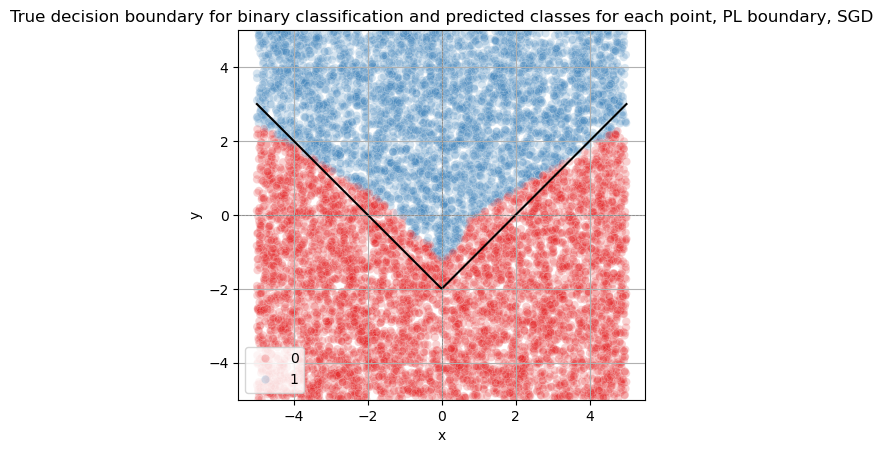

In [25]:
x = np.linspace(-5, 5, 400)
y = np.abs(x) - 2
plt.plot(x, y, color='k', linestyle='solid')
sns.scatterplot(x=X[:,0], y=X[:,1], hue=y_pred_sgd.ravel(), palette='Set1', alpha=0.2)

# Add labels and title
plt.xlabel('x')
plt.ylabel('y')
plt.title("True decision boundary for binary classification and predicted classes for each point, PL boundary, SGD")
plt.grid(True)
plt.ylim(-5,5)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.5)
plt.gca().set_aspect('equal', adjustable='box') # Ensure proper aspect ratio
plt.show()

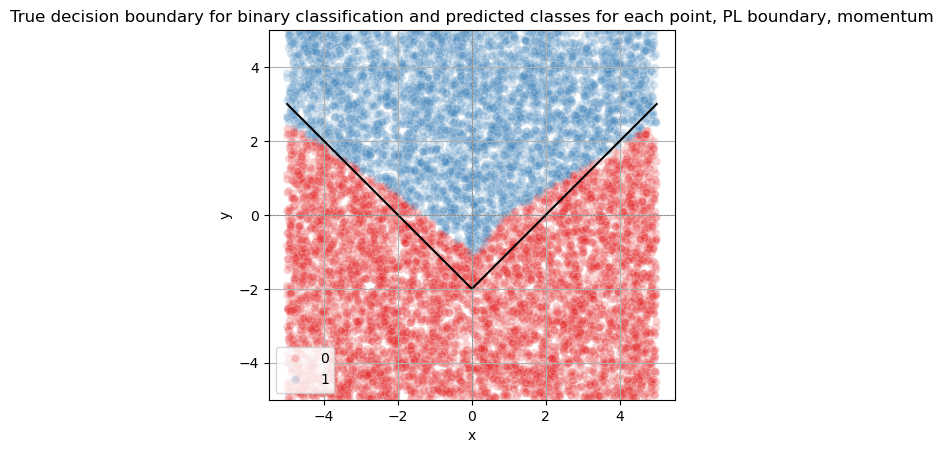

In [26]:
x = np.linspace(-5, 5, 400)
y = np.abs(x) - 2
plt.plot(x, y, color='k', linestyle='solid')
sns.scatterplot(x=X[:,0], y=X[:,1], hue=y_pred_mom.ravel(), palette='Set1', alpha=0.2)

# Add labels and title
plt.xlabel('x')
plt.ylabel('y')
plt.title("True decision boundary for binary classification and predicted classes for each point, PL boundary, momentum")
plt.grid(True)
plt.ylim(-5,5)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.5)
plt.gca().set_aspect('equal', adjustable='box') # Ensure proper aspect ratio
plt.show()

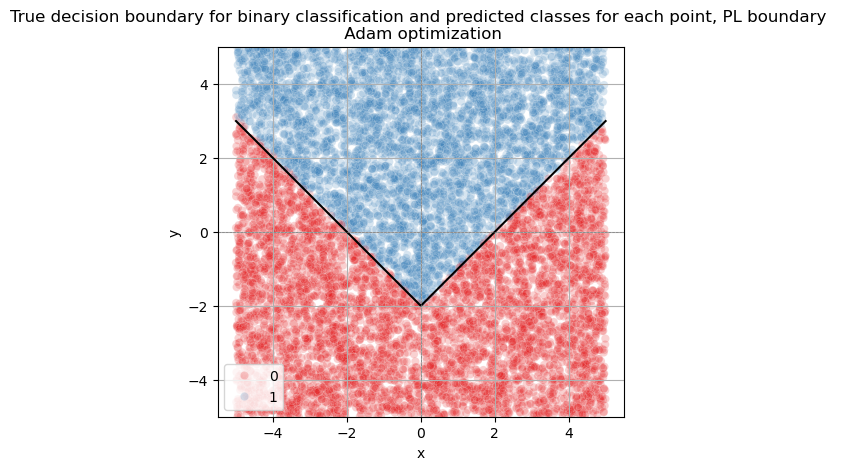

In [27]:
x = np.linspace(-5, 5, 400)
y = np.abs(x) - 2
plt.plot(x, y, color='k', linestyle='solid')
sns.scatterplot(x=X[:,0], y=X[:,1], hue=y_pred_adam.ravel(), palette='Set1', alpha=0.2)

# Add labels and title
plt.xlabel('x')
plt.ylabel('y')
plt.title("True decision boundary for binary classification and predicted classes for each point, PL boundary \n Adam optimization")
plt.grid(True)
plt.ylim(-5,5)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.5)
plt.gca().set_aspect('equal', adjustable='box') # Ensure proper aspect ratio
plt.show()